In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [53]:
df = pd.read_csv("data/dataset.csv")
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [54]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,970.000000,1000.000000
mean,500.500000,10.059970,16.982000,4.579381,56.732000
std,288.819436,5.696656,7.204553,2.914394,22.070915
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,250.750000,5.105000,11.000000,2.000000,41.000000
50%,500.500000,10.190000,17.000000,5.000000,55.500000
75%,750.250000,15.017500,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


In [55]:
df.isnull().sum()
df = df.dropna()

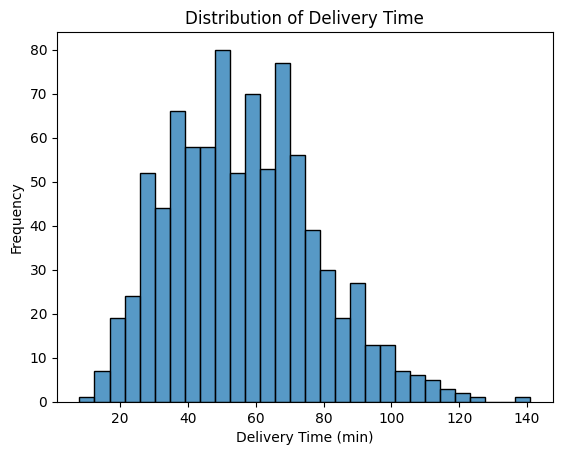

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.histplot(df["Delivery_Time_min"], bins=30)
plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (min)")
plt.ylabel("Frequency")
plt.show()

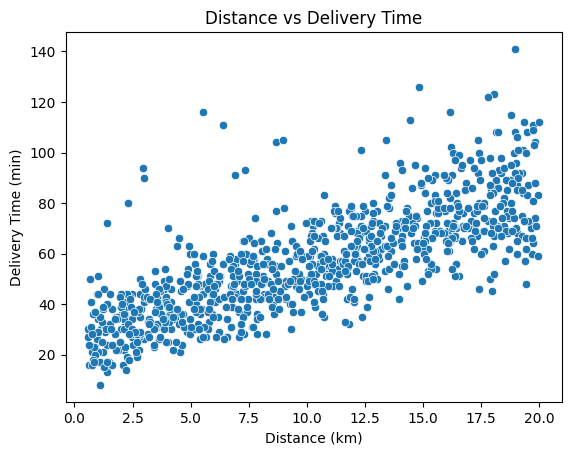

In [57]:
plt.figure()
sns.scatterplot(x=df["Distance_km"], y=df["Delivery_Time_min"])
plt.title("Distance vs Delivery Time")
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (min)")
plt.show()

In [58]:
df = pd.get_dummies(df, drop_first=True)

In [59]:
from sklearn.model_selection import train_test_split

X = df.drop(["Order_ID", "Delivery_Time_min"], axis=1)
y = df["Delivery_Time_min"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [60]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

In [61]:
models = {
    "Linear": LinearRegression(),
    "RandomForest": RandomForestRegressor(),
    "GradientBoosting": GradientBoostingRegressor()
}
results = {}

In [62]:
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    results[name] = mae
    print(f"{name} MAE:", mae)

Linear MAE: 5.319617041145192
RandomForest MAE: 7.00683615819209
GradientBoosting MAE: 6.566386816393138


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [5, 10]
}

grid = GridSearchCV(RandomForestRegressor(), param_grid, cv=3)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
print(grid.best_params_)

In [ ]:
preds = best_model.predict(X_test)
mae = mean_absolute_error(y_test, preds)
print("Final MAE:", mae)

Final MAE: 6.856685359827846


In [ ]:
results_df = pd.DataFrame.from_dict(results, orient='index', columns=['MAE'])
results_df.sort_values(by="MAE")

,MAE
Linear,5.319617
GradientBoosting,6.566387
RandomForest,6.919096


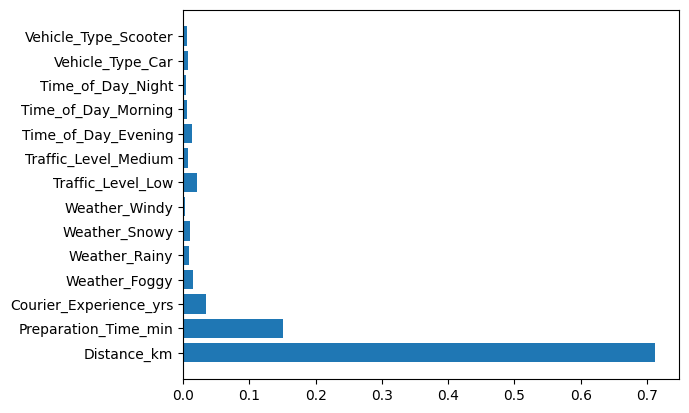

In [ ]:
importances = best_model.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.show()

In [ ]:
import joblib
joblib.dump(best_model, "models/model.joblib")
joblib.dump(X.columns.tolist(), "models/columns.joblib")

['models/columns.joblib']

In [ ]:
print(X.columns.tolist())

['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs', 'Weather_Foggy', 'Weather_Rainy', 'Weather_Snowy', 'Weather_Windy', 'Traffic_Level_Low', 'Traffic_Level_Medium', 'Time_of_Day_Evening', 'Time_of_Day_Morning', 'Time_of_Day_Night', 'Vehicle_Type_Car', 'Vehicle_Type_Scooter']
